In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/digit-recognizer/sample_submission.csv
/kaggle/input/competitions/digit-recognizer/train.csv
/kaggle/input/competitions/digit-recognizer/test.csv


In [85]:
df = pd.read_csv('/kaggle/input/competitions/digit-recognizer/train.csv')

In [65]:
df.sample()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
8084,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [7]:
import matplotlib.pyplot as plt


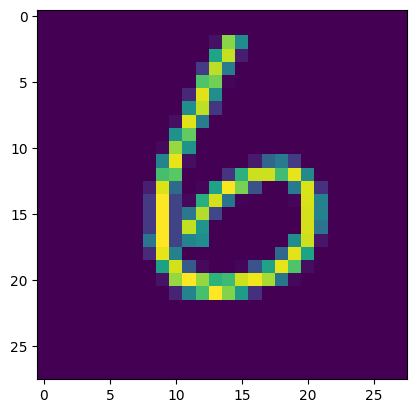

In [12]:
plt.imshow(df.iloc[24310,1:].values.reshape(28,28))

In [89]:
x=df.iloc[:,1:]#input
y=df.iloc[:,0]#target

In [90]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)


In [22]:
X_train.shape

(33600, 784)

In [24]:
from sklearn.neighbors import KNeighborsClassifier


In [25]:
knn = KNeighborsClassifier()

In [26]:
knn.fit(X_train,y_train)

KNeighborsClassifier()

In [29]:
import time
start = time.time()
y_pred=knn.predict(X_test)
print(time.time()-start)

8.65660309791565


In [31]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.9648809523809524

In [94]:
from sklearn.preprocessing import StandardScaler 
scaler = StandardScaler()

In [95]:
X_train_scaled  = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [96]:
#pcs
from sklearn.decomposition import PCA
pca = PCA(n_components=100)

In [97]:
x_train_pca = pca.fit_transform(X_train_scaled)
x_test_pca= pca.fit_transform(X_test_scaled)

In [98]:
x_train_pca.shape

(33600, 100)

In [99]:
knn = KNeighborsClassifier()

In [101]:
knn.fit(x_train_pca,y_train)

KNeighborsClassifier()

In [102]:
y_pred = knn.predict(x_test_pca)

In [105]:
accuracy_score(y_test,y_pred)

0.07047619047619047